In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
#pembacaan dataset
data = pd.read_csv('Computer Science.csv')

In [3]:
#menampilkan 5 data terakhir
data.tail()

,Rank,Sourceid,Title,Type,Issn,SJR,SJR Best Quartile,H index,Total Docs. (2020),Total Docs. (3years),Total Refs.,Total Cites (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Country,Region,Publisher,Coverage,Categories
1635,1636,18800,Kyokai Joho Imeji Zasshi/Journal of the Instit...,journal,13426907,"0,100",Q4,12,28,224,242,10,216,0.05,8.64,Japan,Asiatic Region,Institute of Image Information and Television ...,1997-2020,Computer Science Applications (Q4); Electrical...
1636,1637,5800207596,Linguistica,journal,"2079312X, 11320214","0,100",Q4,4,17,60,520,3,54,0.02,30.59,Uruguay,Latin America,Asociación de Lingüistica y Filología de la Am...,2012-2019,Artificial Intelligence (Q4); Language and Lin...
1637,1638,21100901898,Revista Digital de Biblioteconomia e Ciencia d...,journal,1678765X,"0,100",Q4,2,33,84,1130,3,84,0.04,34.24,Brazil,Latin America,Universidade Estadual de Campinas,2018-2020,Education (Q4); Information Systems (Q4); Libr...
1638,1639,6000153223,Technoetic Arts,journal,1477965X,"0,100",Q4,5,0,87,0,3,84,0.02,0.00,United Kingdom,Western Europe,Intellect Ltd.,2012-2019,Computer Science Applications (Q4); Human-Comp...
1639,1640,21100900060,"Tekst, Kniga, Knigoizdaniye",journal,"23062061, 23113774","0,100",Q4,1,27,51,542,1,51,0.02,20.07,Russian Federation,Eastern Europe,Tomsk State University - Faculty of Philology,2018-2020,Communication (Q4); Information Systems (Q4); ...


In [4]:
#mendescripsikan dataset secara stastistikal
data.describe()

,Rank,Sourceid,H index,Total Docs. (2020),Total Docs. (3years),Total Refs.,Total Cites (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.
count,1640.000000,1.640000e+03,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000
mean,820.500000,1.087724e+10,42.547561,136.547561,301.749390,5740.973780,1225.067683,293.660976,2.745689,39.283085
std,473.571536,9.871728e+09,45.709005,611.076740,892.587578,31751.234985,4591.452066,886.697677,3.267440,28.751912
min,1.000000,1.212500e+04,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,410.750000,2.502050e+04,13.000000,22.000000,61.000000,755.750000,69.000000,57.750000,0.890000,27.570000
50%,820.500000,1.210015e+10,27.000000,47.000000,122.500000,1702.500000,233.000000,115.000000,1.850000,37.185000
75%,1230.250000,2.110040e+10,56.000000,111.000000,276.000000,4428.750000,787.500000,262.250000,3.530000,48.092500
max,1640.000000,2.110102e+10,390.000000,18036.000000,24267.000000,833161.000000,116691.000000,24200.000000,69.560000,811.000000


In [5]:
#melihat apakah ada data yang missing value
data.isnull().sum()

,0
Rank,0
Sourceid,0
Title,0
Type,0
Issn,0
SJR,0
SJR Best Quartile,0
H index,0
Total Docs. (2020),0
Total Docs. (3years),0


In [6]:
data.shape

(1640, 20)

In [7]:
data.dtypes

,0
Rank,int64
Sourceid,int64
Title,object
Type,object
Issn,object
SJR,object
SJR Best Quartile,object
H index,int64
Total Docs. (2020),int64
Total Docs. (3years),int64


In [8]:
#data transformation
from sklearn.preprocessing import LabelEncoder
data['SJR'] = data['SJR'].astype(str).str.replace(',', '.').astype(float)
categorical_cols = ['Title', 'Type', 'Issn', 'SJR Best Quartile', 'Country', 'Region', 'Publisher', 'Categories']

LabelEncoder=LabelEncoder()
for col in categorical_cols:
    data[col] = LabelEncoder.fit_transform(data[col].astype(str))

data.tail()

,Rank,Sourceid,Title,Type,Issn,SJR,SJR Best Quartile,H index,Total Docs. (2020),Total Docs. (3years),Total Refs.,Total Cites (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Country,Region,Publisher,Coverage,Categories
1635,1636,18800,1267,0,297,0.1,3,12,28,224,242,10,216,0.05,8.64,30,2,196,1997-2020,946
1636,1637,5800207596,1281,0,1182,0.1,3,4,17,60,520,3,54,0.02,30.59,63,4,35,2012-2019,234
1637,1638,21100901898,1469,0,704,0.1,3,2,33,84,1130,3,84,0.04,34.24,6,4,422,2018-2020,1043
1638,1639,6000153223,1559,0,432,0.1,3,5,0,87,0,3,84,0.02,0.00,61,8,208,2012-2019,951
1639,1640,21100900060,1564,0,1373,0.1,3,1,27,51,542,1,51,0.02,20.07,45,3,407,2018-2020,366


In [9]:
data['SJR Best Quartile'].unique()

array([0, 1, 2, 3])

In [10]:
#pemilihan attribut/feature yang akan digunakan sebagai variabel independen dan kelas target
x = data.iloc[:, [7, 8, 9, 10, 11, 12, 13, 14]].values
y = data.iloc[:, 6].values

In [11]:
print(x)

[[1.480e+02 8.700e+01 1.780e+02 ... 1.560e+02 1.039e+01 7.002e+01]
 [1.450e+02 7.100e+01 2.080e+02 ... 2.080e+02 6.490e+00 5.085e+01]
 [5.600e+01 1.620e+02 4.410e+02 ... 3.220e+02 1.138e+01 3.641e+01]
 ...
 [2.000e+00 3.300e+01 8.400e+01 ... 8.400e+01 4.000e-02 3.424e+01]
 [5.000e+00 0.000e+00 8.700e+01 ... 8.400e+01 2.000e-02 0.000e+00]
 [1.000e+00 2.700e+01 5.100e+01 ... 5.100e+01 2.000e-02 2.007e+01]]


In [12]:
print(y)

[0 0 0 ... 3 3 3]


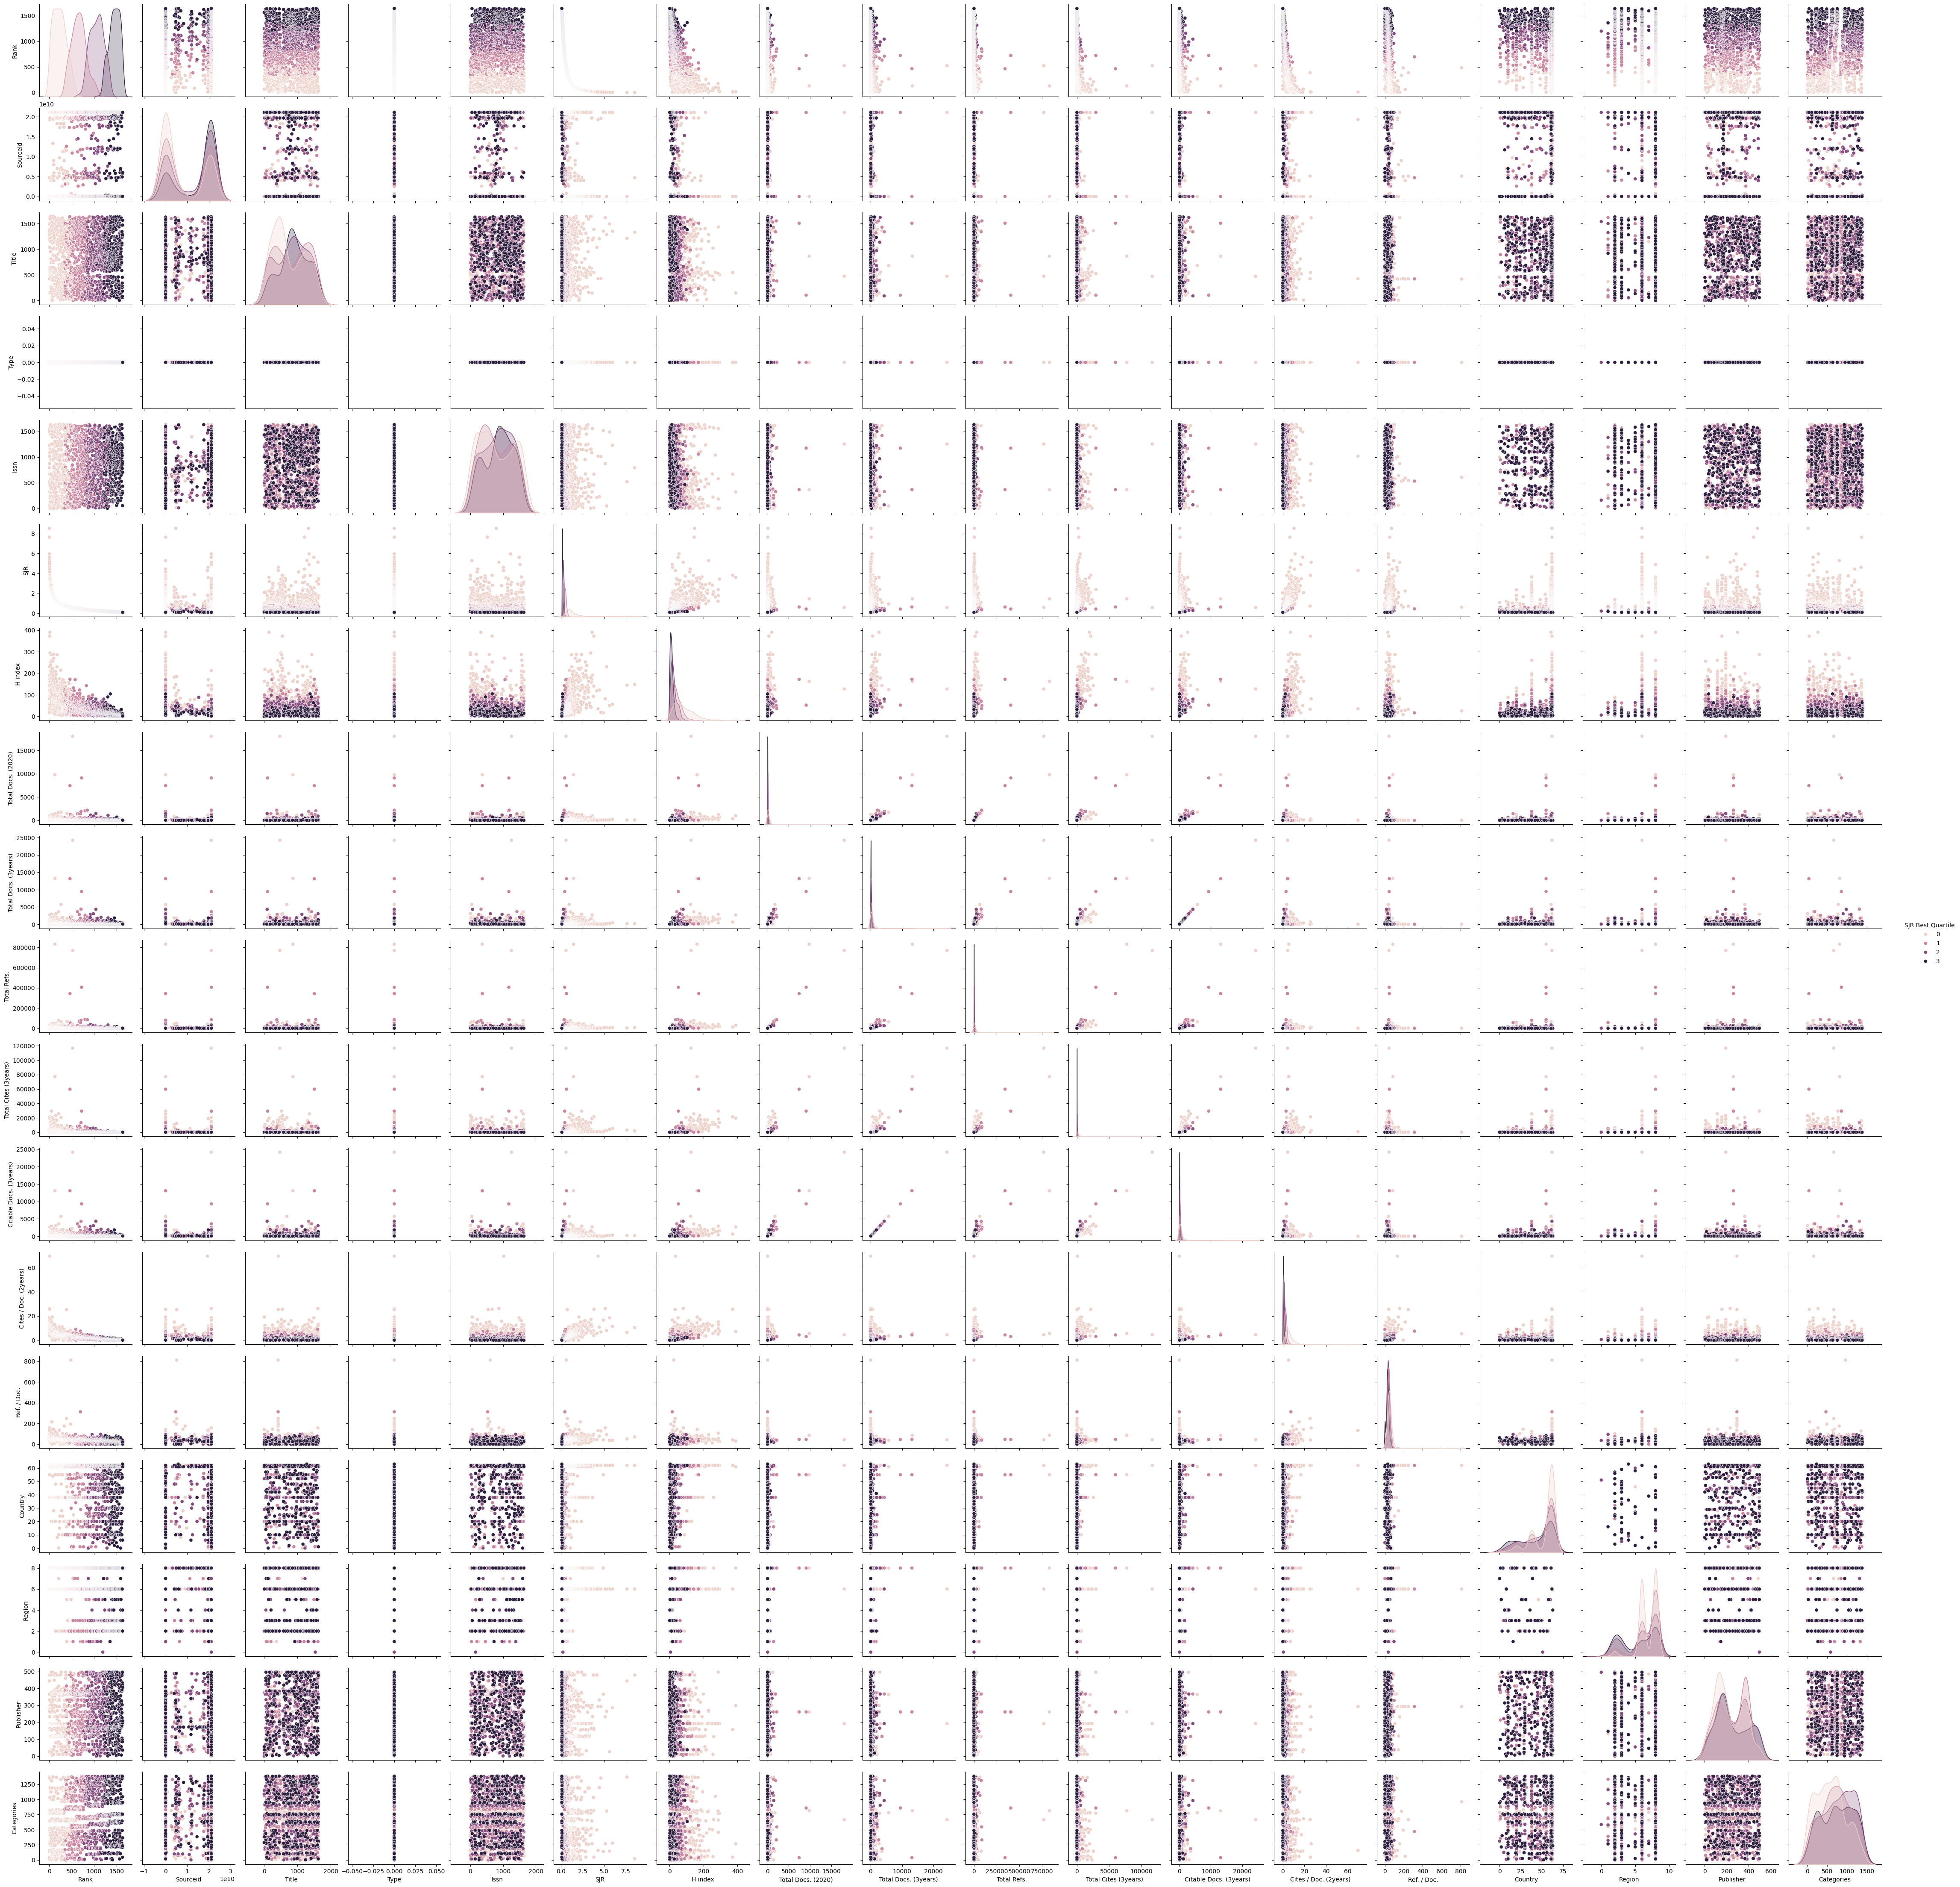

In [13]:
#visualisasi hubungan antar variabel pada dataset
sns.pairplot(data, hue='SJR Best Quartile')

In [15]:
data.drop(columns=['Coverage']).corr()

,Rank,Sourceid,Title,Type,Issn,SJR,SJR Best Quartile,H index,Total Docs. (2020),Total Docs. (3years),Total Refs.,Total Cites (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Country,Region,Publisher,Categories
Rank,1.000000,0.312424,0.105721,NaN,0.070343,-0.711615,0.950587,-0.623923,-0.119489,-0.158598,-0.123874,-0.273994,-0.155227,-0.644820,-0.322690,-0.225688,-0.291282,0.072603,0.169355
Sourceid,0.312424,1.000000,0.020930,NaN,0.515685,-0.209379,0.287134,-0.548345,-0.064655,-0.134228,-0.062532,-0.139791,-0.132510,-0.172458,-0.077916,-0.060612,-0.147743,0.026555,-0.014176
Title,0.105721,0.020930,1.000000,NaN,-0.010661,-0.020908,0.109985,-0.087854,-0.022523,-0.018280,-0.017104,-0.044204,-0.018354,-0.093488,-0.056319,-0.112773,-0.063966,0.163198,0.066528
Type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issn,0.070343,0.515685,-0.010661,NaN,1.000000,-0.053269,0.058964,-0.239695,-0.016553,-0.044484,-0.019540,-0.029848,-0.044620,-0.011625,-0.032212,0.021697,-0.024356,-0.046360,-0.029678
SJR,-0.711615,-0.209379,-0.020908,NaN,-0.053269,1.000000,-0.628335,0.605185,0.077655,0.113212,0.085594,0.280548,0.109800,0.714356,0.257007,0.193093,0.154521,-0.051262,-0.161685
SJR Best Quartile,0.950587,0.287134,0.109985,NaN,0.058964,-0.628335,1.000000,-0.573856,-0.124754,-0.160420,-0.125230,-0.257093,-0.157029,-0.594295,-0.308561,-0.216741,-0.270500,0.074767,0.164044
H index,-0.623923,-0.548345,-0.087854,NaN,-0.239695,0.605185,-0.573856,1.000000,0.228800,0.330811,0.214016,0.480690,0.327380,0.539781,0.153918,0.195863,0.177761,-0.147091,-0.122662
Total Docs. (2020),-0.119489,-0.064655,-0.022523,NaN,-0.016553,0.077655,-0.124754,0.228800,1.000000,0.959848,0.951107,0.894147,0.959757,0.097355,0.021466,0.024127,0.034845,-0.019744,-0.036289
Total Docs. (3years),-0.158598,-0.134228,-0.018280,NaN,-0.044484,0.113212,-0.160420,0.330811,0.959848,1.000000,0.902266,0.925685,0.999738,0.120391,0.008757,0.018506,0.024565,-0.040140,-0.058005


In [16]:
#pembagian rasio data training dan data testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, shuffle=True, stratify=y, random_state = 0)

In [17]:
#standarisasi data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(x_train)
x_train = sc.transform(x_train)
x_test = sc.transform(x_test)

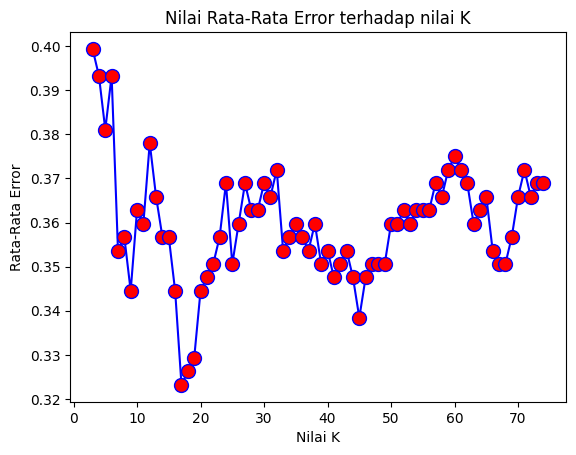

In [18]:
#menentukan konstanta nilai K
from sklearn.neighbors import KNeighborsClassifier
error = []

for i in range (3, 75):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(x_train, y_train)

  pred_i = knn.predict(x_test)
  error.append(np.mean(pred_i != y_test))

plt.figure()
plt.plot(range(3, 75), error, color='blue', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Nilai Rata-Rata Error terhadap nilai K')
plt.xlabel('Nilai K')
plt.ylabel('Rata-Rata Error')
plt.show()

In [19]:
# training
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors= 47)
classifier.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=47)

In [20]:
#testing
y_pred = classifier.predict(x_test)

In [21]:
#evaluasi
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[61 22  3  3]
 [11 54 17  1]
 [ 0 26 42 16]
 [ 0  0 16 56]]
              precision    recall  f1-score   support

           0       0.85      0.69      0.76        89
           1       0.53      0.65      0.58        83
           2       0.54      0.50      0.52        84
           3       0.74      0.78      0.76        72

    accuracy                           0.65       328
   macro avg       0.66      0.65      0.65       328
weighted avg       0.66      0.65      0.65       328



In [22]:
#menampilkan nilai akurasi
from sklearn.metrics import accuracy_score
accuracy= accuracy_score(y_test, y_pred)*100
print('Accuracy of our model is equal' + str(round(accuracy, 2))+'%')

Accuracy of our model is equal64.94%


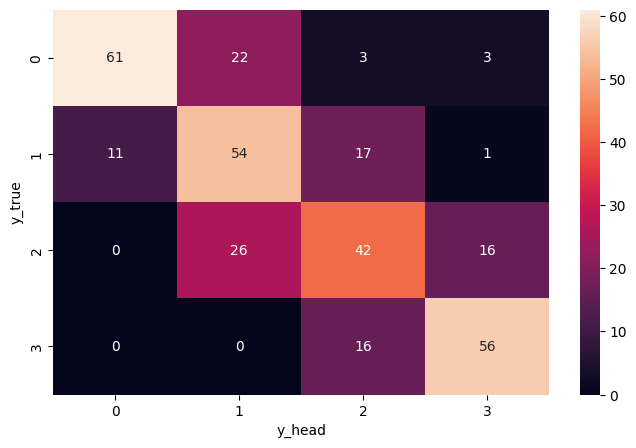

In [23]:
#visualiasi dari confusion matrix
f, ax = plt.subplots(figsize=(8,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt=".0f",ax=ax)
plt.xlabel("y_head")
plt.ylabel('y_true')
plt.show()

<Figure size 640x480 with 0 Axes>

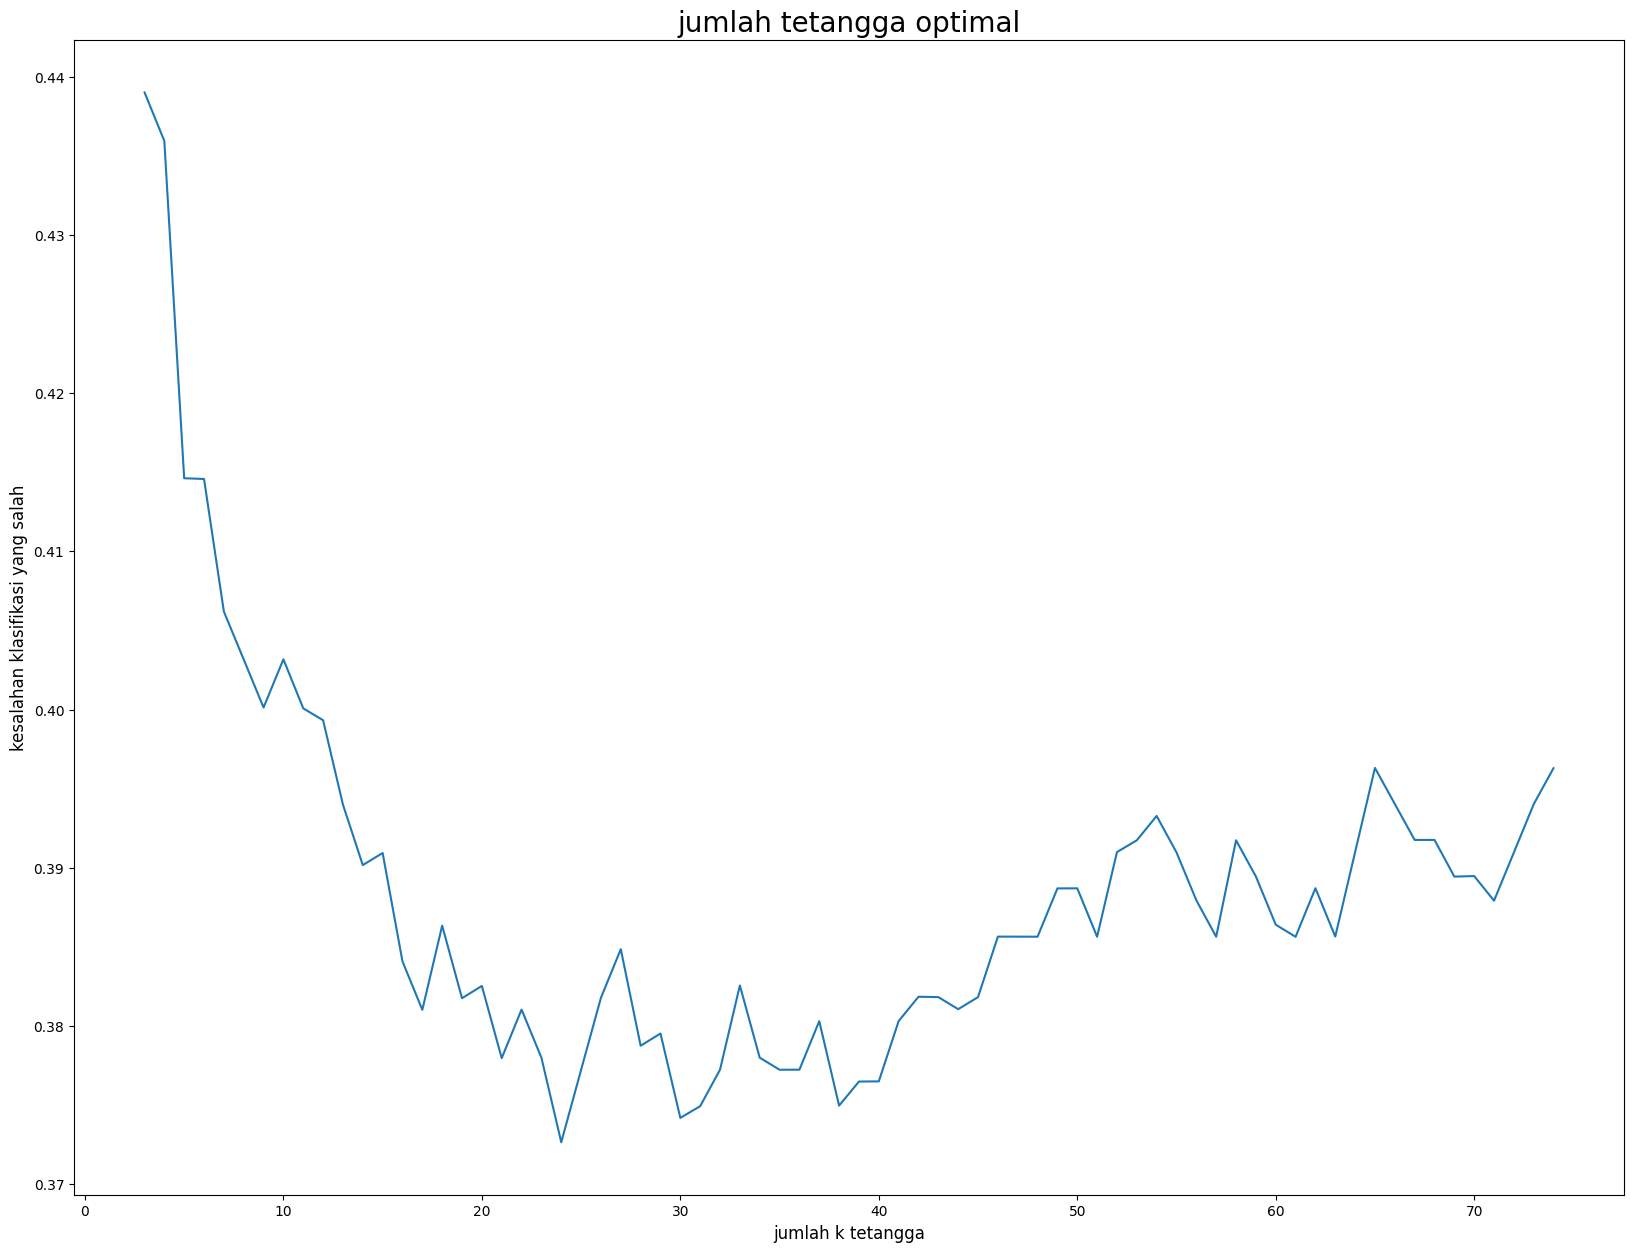

In [24]:
from IPython.core.pylabtools import figsize
#grafik nilai K optimal
from sklearn.model_selection import cross_val_score
#list nilai K untuk KNN
k_list = list(range(3,75))
cv_scores =[]
#10-fold cross validation
for k in k_list:
  knn = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(knn, x_train, y_train, cv=10, scoring='accuracy')
  cv_scores.append(scores.mean())
#kesalahan klasifikasi yang salah
MSE = [1 - x for x in cv_scores]
plt.figure()
plt.figure(figsize=(20,15))
plt.title('jumlah tetangga optimal', fontsize=20)
plt.xlabel('jumlah k tetangga', fontsize= 12)
plt.ylabel('kesalahan klasifikasi yang salah', fontsize=12)
sns.set_style("whitegrid")
plt.plot(k_list, MSE)
plt.show()

In [25]:
from scipy.stats.stats import ks_2samp
#mencari k terbaik
best_k = k_list[MSE.index(min(MSE))]
print("number of neighbour optimal is %d." % best_k)

number of neighbour optimal is 24.


/tmp/ipykernel_3097/3014905289.py:1: DeprecationWarning: Please import `ks_2samp` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import ks_2samp


In [26]:
# retrain final model menggunakan K optimal hasil cross-validation
classifier_optimal = KNeighborsClassifier(n_neighbors=best_k)
classifier_optimal.fit(x_train, y_train)

y_pred_optimal = classifier_optimal.predict(x_test)

print(f"=== Hasil dengan K optimal (K={best_k}) ===")
print(confusion_matrix(y_test, y_pred_optimal))
print(classification_report(y_test, y_pred_optimal))

accuracy_optimal = accuracy_score(y_test, y_pred_optimal) * 100
print(f'Accuracy dengan K={best_k}: {round(accuracy_optimal, 2)}%')

=== Hasil dengan K optimal (K=24) ===
[[62 21  3  3]
 [14 47 21  1]
 [ 1 25 42 16]
 [ 0  0 16 56]]
              precision    recall  f1-score   support

           0       0.81      0.70      0.75        89
           1       0.51      0.57      0.53        83
           2       0.51      0.50      0.51        84
           3       0.74      0.78      0.76        72

    accuracy                           0.63       328
   macro avg       0.64      0.64      0.64       328
weighted avg       0.64      0.63      0.63       328

Accuracy dengan K=24: 63.11%
